![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 3. Circuits and Compact Models

 ## 0.1 Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import logging
import sys
from functools import partial
from pprint import pprint

import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from numpy.fft import fft2, fftfreq, fftshift, ifft2
from rich.logging import RichHandler
from scipy import constants
from sklearn.linear_model import LinearRegression
from tqdm.notebook import trange
from scipy.constants import c as c0

import gplugins.sax as gs
import gplugins.tidy3d as gt
from gplugins.common.config import PATH

logger = logging.getLogger()
logger.removeHandler(sys.stderr)
logging.basicConfig(level="WARNING", datefmt="[%X]", handlers=[RichHandler()])

/tmp/ipykernel_1297/616826865.py:17: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


## 0.2 Compact Models for simulations

### 0.2.1. Waveguide compact model (Lab1. LO4)

We start from the waveguide's effective index second degree polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Or from the parameters derived from the polynomial coefficients: 
 
$$
n_\mathrm{eff}(\lambda_0) = n_1~ ;~ n_g(\lambda_0) = n_1 - n_2\,\lambda_0~;~ D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

The transmmission through the waveguide should be modeled as: 

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$
With  
$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

We are going to use [SAX](https://pypi.org/project/sax/), a scatter parameter circuit simulator, to implement simulations in the frequency (wavelength) domain. The following cell demonstrates how to define the most basic component transfer function: 

In [2]:
# The model should be a Python function that takes as input the relevant parameters
# (e.g., wavelength, effective index, length, loss) and returns a SAX SDict representing
# the waveguide's S-parameters.
# Parameters:
# wl: Wavelength to simulate (um)
# wl0: Reference wavelength - where you calculated the group index and dispersion (um))
# neff: Effective index at the reference wavelength (au)
# ng: Group index (au)
# length: Length of the waveguide in micrometers (um)
# loss: Propagation loss in dB/um (Experimental value)
# D: Dispersion parameter (s^2/m)
def waveguide(wl=1.55, wl0=1.55, neff=1.6072, ng=2.0, length=10.0, loss=0.0, D=0) -> sax.SDict:
    dwl = wl - wl0
    n1 = neff
    n2 = (n1-ng)/wl0
    n3 = -D*c0/(2*wl0)
    neff = n1 + n2*dwl + n3*dwl**2
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict

### 0.2.2. Coupler compact model (Lab2 LO6)

We can start with the ideal coupler transfer function. You can then update your model with the parameters you found in your Laboratory 2. The model we are going to implement does not take into account if the coupler is an MMI or a Directional Coupler, it just use as parameters the coupling coefficient to calculate the output power at each port. 

$$
\begin{pmatrix}
E_{o1}\\
E_{o2}
\end{pmatrix}
=
\begin{pmatrix}
\sqrt{1-K} & -\mathrm{j}\sqrt{K}\\
-\mathrm{j}\sqrt{K} & \sqrt{1-K}
\end{pmatrix}
\begin{pmatrix}
E_{i1}\\
E_{i2}
\end{pmatrix}
$$

In [3]:
# Coupler Model
# We define again the Python function for the coupler compact model.
# Parameters:
# coupling: Coupling coefficient (between 0 and 1)
# You MUST update the model with the parameters you found in your Laboratory 2: 
# Excess loss, actual phase shift.
def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    # The coupler is a reciprocal device, so we use sax.reciprocal to create the SDict
    # (reciprocal device means it behaves the same way in both directions)
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict


## LO.1. Mach - Zehnder Interferometer

### 1.1. MZI Circuit Model

Using SAX library, we can now define the components, connections and models needed to build our circuit. Let's start with the MZI: 

<img src="mzi.png" alt="mzi circuit" width="600">

We will need two couplers and two waveguides: 


In [4]:
# MZI Circuit
# We will define instances, connections and ports for the MZI circuit using the SAX library.
# We will use the coupler and waveguide models defined above.
mzi, info = sax.circuit(
    netlist={
        # Define instances of couplers and waveguides
        "instances": {
            "coup_E": "coupler",
            "wvg_N": "waveguide",
            "wvg_S": "waveguide",
            "coup_W": "coupler",
        },
        # Define connections between the instances
        "connections": {
            "coup_E,out0": "wvg_S,in0",
            "wvg_S,out0": "coup_W,in0",
            "coup_E,out1": "wvg_N,in0",
            "wvg_N,out0": "coup_W,in1",
        },
        # Define the external ports of the MZI circuit
        "ports": {
            "in0": "coup_E,in0",
            "in1": "coup_E,in1",
            "out0": "coup_W,out0",
            "out1": "coup_W,out1",
        },
    },
    # Important! Provide here the models for the components used in the circuit
    # Here we use the coupler and waveguide functions defined above
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


[18:23:52] WARNING  WARNING:jax._src.xla_bridge:An NVIDIA GPU may be present on this machine, but ]8;id=767850;file:///home/manuel/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py\xla_bridge.py]8;;\:]8;id=531050;file:///home/manuel/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py#864\864]8;;\
                    a CUDA-enabled jaxlib is not installed. Falling back to cpu.                                   

Using this circuit model, it is possible now to perform simulations to obtain the MZI response:

Text(0, 0.5, '|H|^2 [dB]')

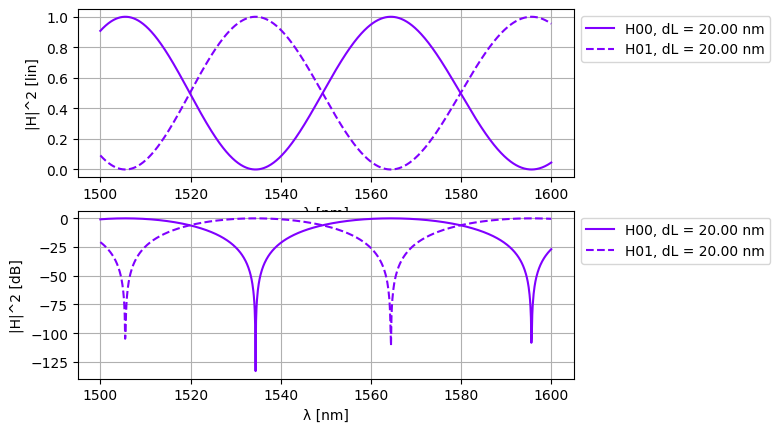

In [5]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 1000)

# Length values to simulate. We have a base length and we will vary the length of one arm using delta_l_v
delta_l_v = np.array([20,]) 
l_base = 10.0

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    # We can access the waveguide lengths by using the instance names defined in the circuit
    # First we instantiate the MZI with the desired lengths
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    # Then we can extract the S-parameters using the port names defined in the circuit
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

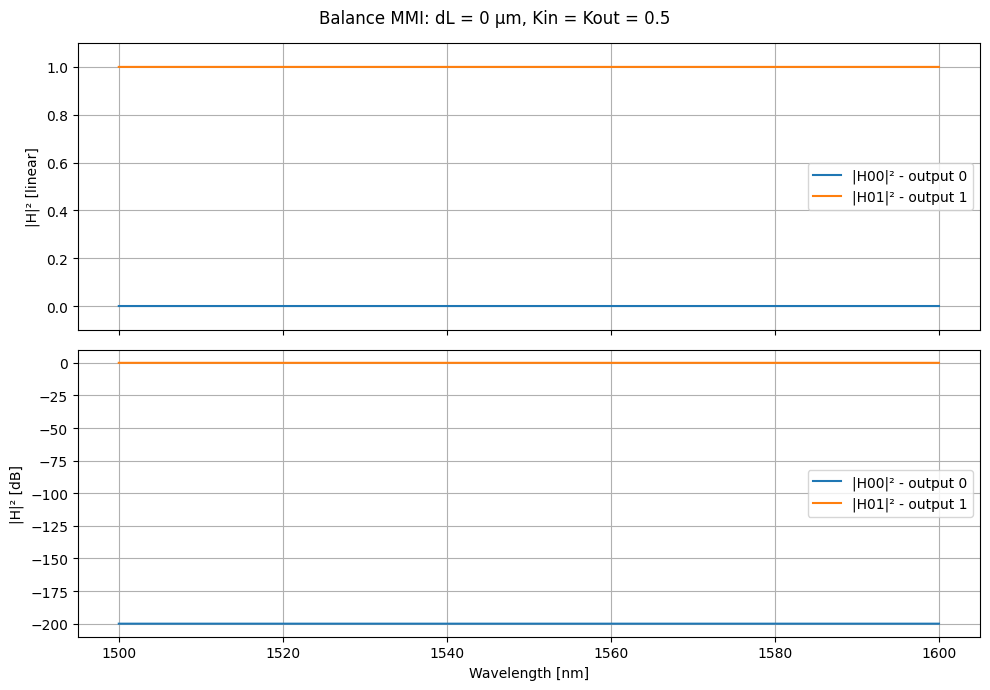

In [6]:

wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)


L_base = 10.0      # longitud base en um
dL = 0.0           # diferencia de longitud entre brazos en um
Kin = 0.5          # acoplador de entrada 50/50
Kout = 0.5         # acoplador de salida 50/50

#l MZI
mzi_test = mzi(
    wl=wl,
    coup_E={"coupling": Kin},
    coup_W={"coupling": Kout},
    wvg_S={"length": L_base},
    wvg_N={"length": L_base + dL},
)

# Extracción de transferencias
H00 = mzi_test["in0", "out0"]
H01 = mzi_test["in0", "out1"]

# Potencia lineal
P00 = np.abs(H00)**2
P01 = np.abs(H01)**2

# Potencia en dB
# evitar log(0)
eps = 1e-20
P00_dB = 10.0 * np.log10(P00 + eps)
P01_dB = 10.0 * np.log10(P01 + eps)


fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax[0].plot(wl * 1e3, P00, label="|H00|² - output 0")
ax[0].plot(wl * 1e3, P01, "-", label="|H01|² - output 1")
ax[0].set_ylabel("|H|² [linear]")
ax[0].set_ylim([-0.1, 1.1])
ax[0].grid(True)
ax[0].legend()

ax[1].plot(wl * 1e3, P00_dB, label="|H00|² - output 0")
ax[1].plot(wl * 1e3, P01_dB, "-", label="|H01|² - output 1")
ax[1].set_xlabel("Wavelength [nm]")
ax[1].set_ylabel("|H|² [dB]")
#ax[1].set_ylim([-60, 5])
ax[1].grid(True)
ax[1].legend()

plt.suptitle("Balance MMI: dL = 0 µm, Kin = Kout = 0.5")
plt.tight_layout()
plt.show()


# no aparece un patrón periódico de interferencia ya que la diferencia de brazos es 0
# funciones transferencia son prácticamente planas en todo el rango 
# salida  interferencia constructiva y  otra salida presenta interferencia destructiva??

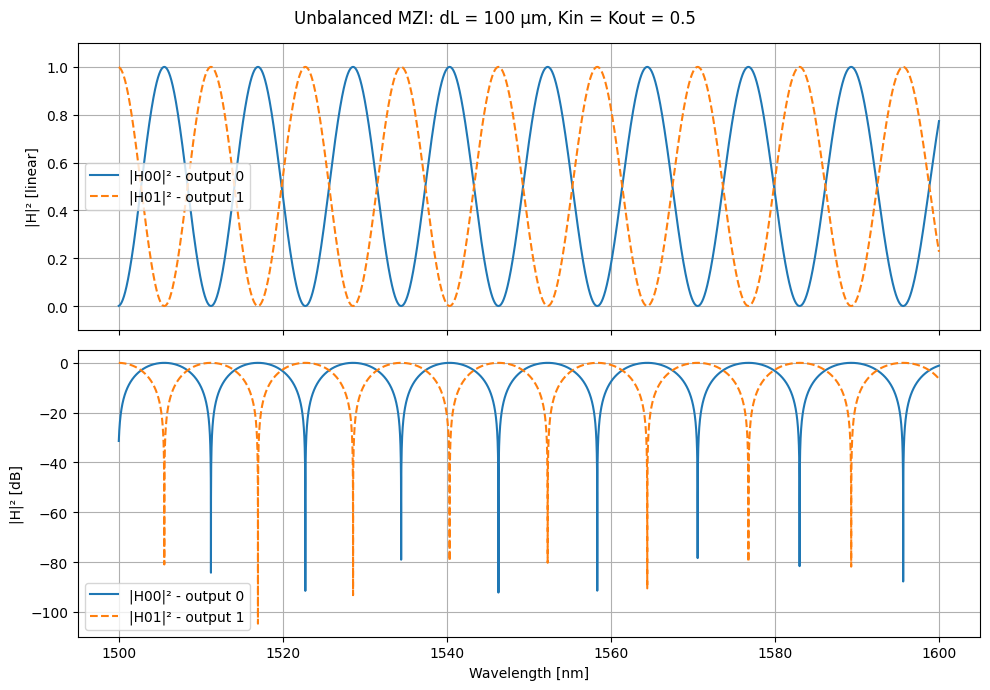

In [7]:
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)   # um

L_base = 10.0     # um
dL = 100.0        # um
Kin = 0.5
Kout = 0.5

mzi_test = mzi(
    wl=wl,
    coup_E={"coupling": Kin},
    coup_W={"coupling": Kout},
    wvg_S={"length": L_base},
    wvg_N={"length": L_base + dL},
)

H00 = mzi_test["in0", "out0"]
H01 = mzi_test["in0", "out1"]

P00 = np.abs(H00)**2
P01 = np.abs(H01)**2

eps = 1e-20
P00_dB = 10*np.log10(P00 + eps)
P01_dB = 10*np.log10(P01 + eps)

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax[0].plot(wl * 1e3, P00, label="|H00|² - output 0")
ax[0].plot(wl * 1e3, P01, "--", label="|H01|² - output 1")
ax[0].set_ylabel("|H|² [linear]")
ax[0].set_ylim([-0.1, 1.1])
ax[0].grid(True)
ax[0].legend()

ax[1].plot(wl * 1e3, P00_dB, label="|H00|² - output 0")
ax[1].plot(wl * 1e3, P01_dB, "--", label="|H01|² - output 1")
ax[1].set_xlabel("Wavelength [nm]")
ax[1].set_ylabel("|H|² [dB]")
#ax[1].set_ylim([-60, 5])
ax[1].grid(True)
ax[1].legend()

plt.suptitle("Unbalanced MZI: dL = 100 µm, Kin = Kout = 0.5")
plt.tight_layout()
plt.show()

In [8]:
from scipy.signal import find_peaks

wl_nm = np.array(wl) * 1e3
P = np.array(P01)   

# Buscar máximos
peaks, props = find_peaks(P, height=0.9, distance=8000)

wl_peaks = wl_nm[peaks]

print("máximos [nm]:")
print(wl_peaks[:10])


fsr_values = np.diff(wl_peaks)
fsr_mean = np.mean(fsr_values)

print("\nFSR entre máximos consecutivos [nm]:")
print(fsr_values[:10])

print(f"\nFSR medio = {fsr_mean:.3f} nm")

máximos [nm]:
[1511.237 1522.743 1534.426 1546.289 1558.337 1570.575 1583.006 1595.635]

FSR entre máximos consecutivos [nm]:
[11.506 11.683 11.863 12.048 12.238 12.431 12.629]

FSR medio = 12.057 nm


In [9]:
# PAra calcular la diferencia de caminos

lambda0_um = 1.55       # 1550 nm = 1.55 um
FSR_nm = 2           # objetivo 
FSR_um = FSR_nm / 1000  # pasar nm a um
ng = 2.0                # índice de grupo 

dL_design = lambda0_um**2 / (ng * FSR_um)  # Ecuacion relaciona FSR y dL

print(f" dL para una FSR de 2nm = {dL_design:.3f} um")

 dL para una FSR de 2nm = 600.625 um


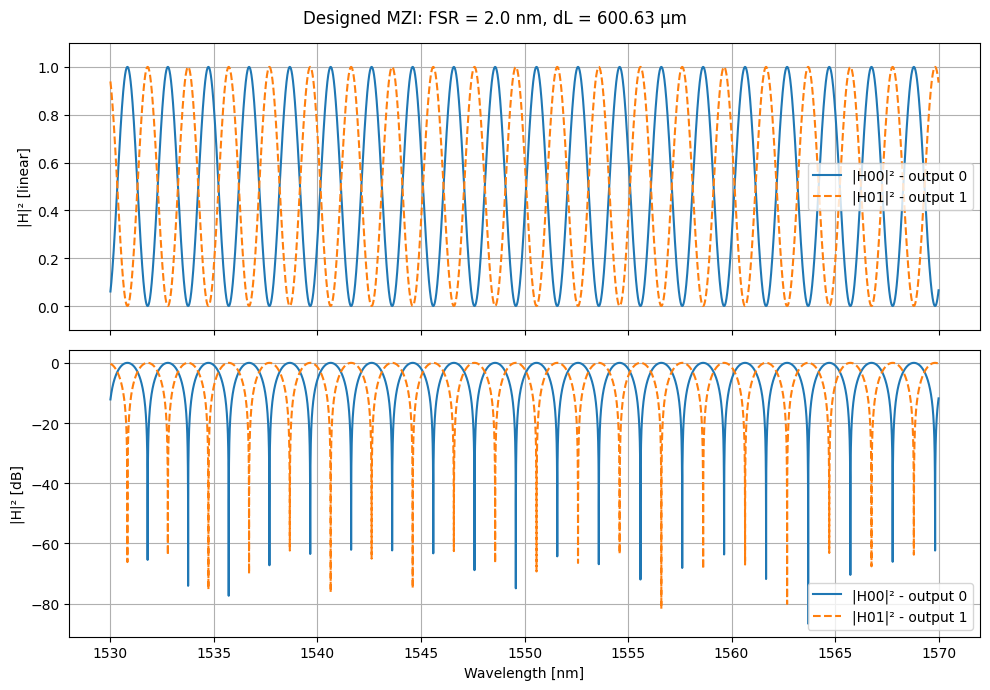

In [10]:
wl = jnp.arange(1.530, 1.570 + 0.000001, 0.000001)   # um

L_base = 10.0
dL = dL_design

Ka = 0.5
Kb = 0.5

mzi_test = mzi(
    wl=wl,
    coup_E={"coupling": Ka},
    coup_W={"coupling": Kb},
    wvg_S={"length": L_base},
    wvg_N={"length": L_base + dL},
)

H00 = mzi_test["in0", "out0"]
H01 = mzi_test["in0", "out1"]

P00 = np.abs(H00)**2
P01 = np.abs(H01)**2

eps = 1e-20
P00_dB = 10*np.log10(P00 + eps)
P01_dB = 10*np.log10(P01 + eps)

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax[0].plot(wl * 1e3, P00, label="|H00|² - output 0")
ax[0].plot(wl * 1e3, P01, "--", label="|H01|² - output 1")
ax[0].set_ylabel("|H|² [linear]")
ax[0].set_ylim([-0.1, 1.1])
ax[0].grid(True)
ax[0].legend()

ax[1].plot(wl * 1e3, P00_dB, label="|H00|² - output 0")
ax[1].plot(wl * 1e3, P01_dB, "--", label="|H01|² - output 1")
ax[1].set_xlabel("Wavelength [nm]")
ax[1].set_ylabel("|H|² [dB]")
ax[1].grid(True)
ax[1].legend()

plt.suptitle(f"Designed MZI: FSR = {FSR_nm:.1f} nm, dL = {dL:.2f} µm")
plt.tight_layout()
plt.show()



#  Cambiaar el rango eje x para que se vea que el FSR es de 2 nm

In [11]:
# Comprobar que el FSR sigue siendo los 2nm

wl_nm = np.array(wl) * 1e3
P = np.array(P01)

# Buscar máximos suficientemente altos
peaks, props = find_peaks(P, height=0.9, distance=1000)

wl_peaks = wl_nm[peaks]

print("Maximos [nm]:")
print(wl_peaks[:10])

fsr_values = np.diff(wl_peaks)
fsr_mean = np.mean(fsr_values)

print("\nFSR  [nm]:")
print(fsr_values[:10])

print(f"\nMedia del FSR = {fsr_mean:.3f} nm")

Maximos [nm]:
[1531.796 1533.752 1535.713 1537.679 1539.65  1541.625 1543.606 1545.593
 1547.584 1549.58 ]

FSR  [nm]:
[1.956 1.961 1.966 1.971 1.975 1.981 1.987 1.991 1.996 2.002]

Media del FSR = 2.002 nm


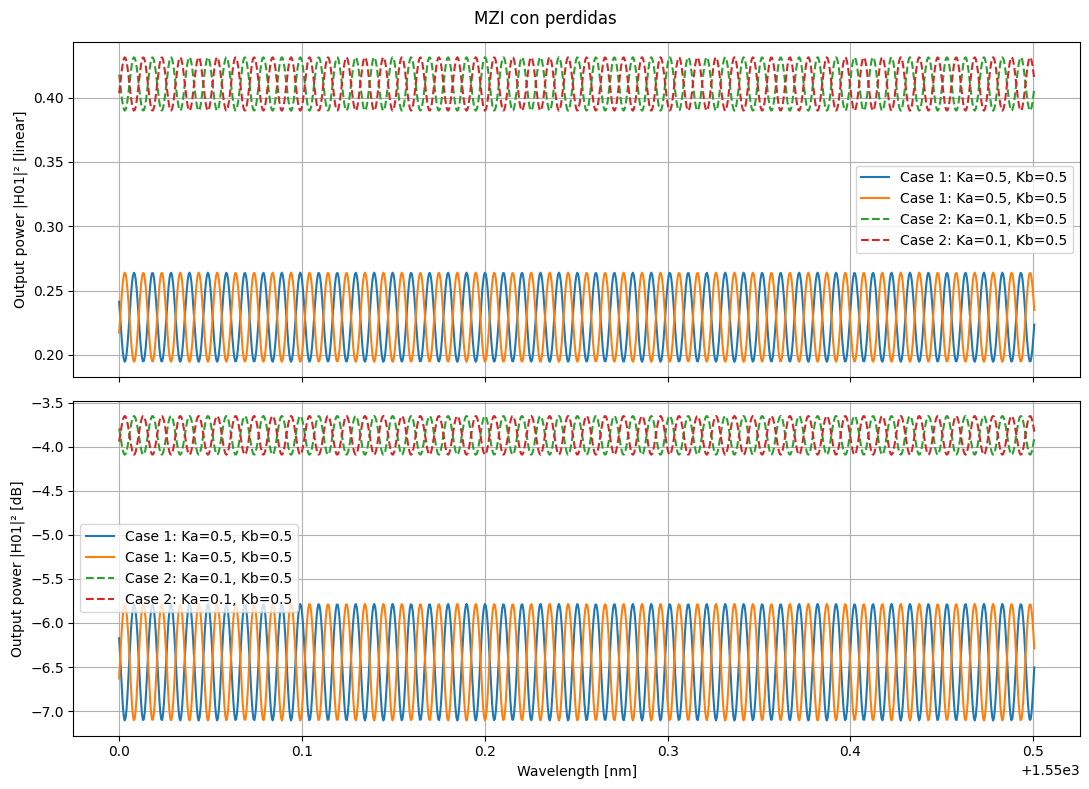

In [12]:
wl = jnp.arange(1.550, 1.5505 + 0.0000005, 0.0000005)

# Parámetros del modelo
neff = 2.38
ng = 4.25
D = 0.0

L_base = 1000.0
L_short = L_base
L_long = L_base + 55960.0840224255

loss_db_per_cm = 4.0
loss_db_per_um = loss_db_per_cm / 10000.0   



def simular_mzi_con_perdidas(Ka, Kb):
    mzi_test = mzi(
        wl=wl,
        coup_E={"coupling": Ka},
        coup_W={"coupling": Kb},
        wvg_S={
            "length": L_short,
            "neff": neff,
            "ng": ng,
            "D": D,
            "loss": loss_db_per_um,
        },
        wvg_N={
            "length": L_long,
            "neff": neff,
            "ng": ng,
            "D": D,
            "loss": loss_db_per_um,
        },
    )

    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    P00 = np.abs(H00)**2
    P01 = np.abs(H01)**2

    eps = 1e-20
    P00_dB = 10*np.log10(P00 + eps)
    P01_dB = 10*np.log10(P01 + eps)

    return P00, P01, P00_dB, P01_dB

# Caso 1
P00_c1, P01_c1, P00dB_c1, P01dB_c1 = simular_mzi_con_perdidas(Ka=0.5, Kb=0.5)

# Caso 2
P00_c2, P01_c2, P00dB_c2, P01dB_c2 = simular_mzi_con_perdidas(Ka=0.1, Kb=0.5)

wl_nm = np.array(wl) * 1e3



fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Lineal - mostramos una salida para comparar claramente
ax[0].plot(wl_nm, P01_c1, label="Case 1: Ka=0.5, Kb=0.5")
ax[0].plot(wl_nm, P00_c1, label="Case 1: Ka=0.5, Kb=0.5")
ax[0].plot(wl_nm, P01_c2, "--", label="Case 2: Ka=0.1, Kb=0.5")
ax[0].plot(wl_nm, P00_c2, "--", label="Case 2: Ka=0.1, Kb=0.5")
ax[0].set_ylabel("Output power |H01|² [linear]")
ax[0].grid(True)
ax[0].legend()

# dB
ax[1].plot(wl_nm, P01dB_c1, label="Case 1: Ka=0.5, Kb=0.5")
ax[1].plot(wl_nm, P00dB_c1, label="Case 1: Ka=0.5, Kb=0.5")
ax[1].plot(wl_nm, P01dB_c2, "--", label="Case 2: Ka=0.1, Kb=0.5")
ax[1].plot(wl_nm, P00dB_c2, "--", label="Case 2: Ka=0.1, Kb=0.5")
ax[1].set_xlabel("Wavelength [nm]")
ax[1].set_ylabel("Output power |H01|² [dB]")
ax[1].grid(True)
ax[1].legend()

plt.suptitle("MZI con perdidas")
plt.tight_layout()
plt.show()

In [13]:
def calcular_metricas(P):
    P = np.asarray(P)
    eps = 1e-20
    Pmax = np.max(P)
    Pmin = np.min(P)

    ER_dB = 10*np.log10((Pmax + eps)/(Pmin + eps))
    visibility = (Pmax - Pmin)/(Pmax + Pmin)

    return Pmax, Pmin, ER_dB, visibility

# Lo calculamos para la salida out1
Pmax1, Pmin1, ER1_dB, V1 = calcular_metricas(P01_c1)
Pmax2, Pmin2, ER2_dB, V2 = calcular_metricas(P01_c2)

print("CASE 1  (Ka=0.5, Kb=0.5)")
print(f"Pmax = {Pmax1:.6f}")
print(f"Pmin = {Pmin1:.6f}")
print(f"ER   = {ER1_dB:.3f} dB")


print("\nCASE 2  (Ka=0.1, Kb=0.5)")
print(f"Pmax = {Pmax2:.6f}")
print(f"Pmin = {Pmin2:.6f}")
print(f"ER   = {ER2_dB:.3f} dB")


CASE 1  (Ka=0.5, Kb=0.5)
Pmax = 0.263975
Pmin = 0.194664
ER   = 1.323 dB

CASE 2  (Ka=0.1, Kb=0.5)
Pmax = 0.431461
Pmin = 0.389875
ER   = 0.440 dB


The resulting interference pattern allows us to determine the **free spectral range** (FSR). By locating two adjacent notches in the transfer function, the difference between their wavelengths gives the FSR, which satisfies:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,\Delta L}
$$

You can use this code section with certain variations for LO1a,1b,2 and 3.

## LO.4. Ring Resonators.

### 1.1. Ring Resonator Circuit Models

We can implement two different variations for the Ring Resonator. The simple ring that consist of a coupler connected with a waveguide (ring_ap), and the double bus ring that needs an extra coupler and the corresponding waveguides to make connections between them (ring_2bus): 

<img src="rings.png" alt="mzi circuit" width="600">


#### 1.1.1. Ring coupled to a single waveguide

We define one circuit per design variation. 

In [14]:
ring_ap, info = sax.circuit(
    netlist={
        "instances": {
            "coup": "coupler",
            "wvg_ring": "waveguide",
        },
        "connections": {
            "coup,out1": "wvg_ring,in0",
            "wvg_ring,out0": "coup,in1",
        },
        "ports": {
            "in0": "coup,in0",
            "out0": "coup,out0"
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

Then we can test the circuit to check the functionality

Text(0, 0.5, '|H|^2 [dB]')

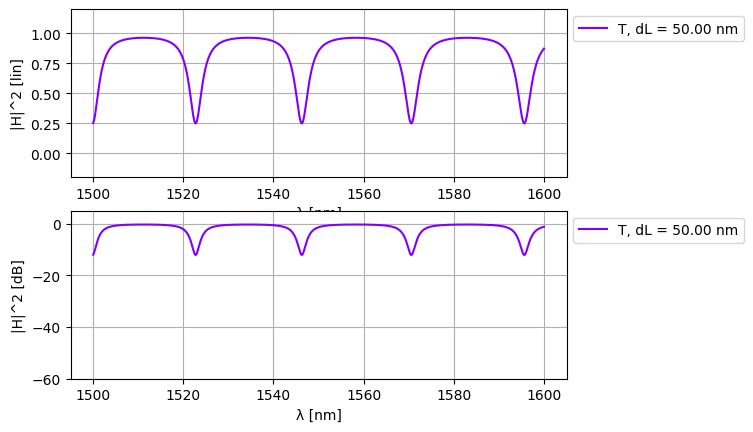

In [15]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([50,]) 

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Here we instantiate the ring resonator with the desired ring length
    # Update this line if you desire to simulate different losses or coupling coefficients
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": delta_l, "loss": 0.02}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

#### 1.1.2. Ring coupled to two waveguides

For this design variation, the ring perimeter is divided into two straight sections that connect both couplers

In [16]:
ring_2bus, info = sax.circuit(
    netlist={
        "instances": {
            "wvg_S_in": "waveguide",
            "wvg_S_out": "waveguide",
            "coup_S": "coupler",
            "wvg_ring_E": "waveguide",
            "wvg_ring_W": "waveguide",
            "coup_N": "coupler",
            "wvg_N_in": "waveguide",
            "wvg_N_out": "waveguide",
        },
        "connections": {
            "wvg_S_in,out0": "coup_S,in0",
            "coup_S,out0": "wvg_S_out,in0",
            "coup_S,out1": "wvg_ring_E,in0",
            "wvg_ring_E,out0": "coup_N,in1",
            "coup_N,out1": "wvg_ring_W,in0",
            "wvg_ring_W,out0": "coup_S,in1",
            "wvg_N_in,out0": "coup_N,in0",
            "coup_N,out0": "wvg_N_out,in0",
        },
        "ports": {
            "in0": "wvg_S_in,in0",
            "out0": "wvg_S_out,out0",
            "in1": "wvg_N_in,in0",
            "out1": "wvg_N_out,out0",
        },
    },
    models= {
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

Test the circuit to check the functionality

Text(0, 0.5, '|H|^2 [dB]')

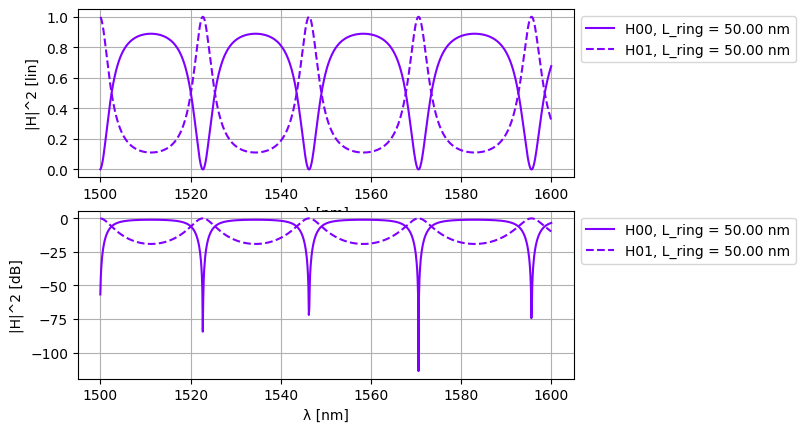

In [44]:
wl = jnp.linspace(1.50, 1.60, 1000)

delta_l_v = np.array([50,]) 

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    #ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l, "loss": 2.0}, coup_N={"coupling": 0.5})
    ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l})
    H00 = ring_2bus_test["in0", "out0"]
    H01 = ring_2bus_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, L_ring = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, L_ring = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, L_ring = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, L_ring = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")


In [18]:
# Rango de longitudes de onda
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)  # um

# Parámetros del anillo
L_ring = 50.0      # perímetro del anillo en um
K = 0.5            # coeficiente de acoplo constante
loss = 0.02        # pérdida en dB/um, 

# Simulación del anillo
ring_test = ring_ap(
    wl=wl,
    wvg_ring={
        "length": L_ring,
        "loss": loss,
    },
    coup={
        "coupling": K,
    },
)

# Transferencia through port
T = ring_test["in0", "out0"]

# Potencia lineal
P = np.abs(T)**2

# Potencia en dB
eps = 1e-20
P_dB = 10*np.log10(P + eps)

wl_nm = np.array(wl) * 1e3

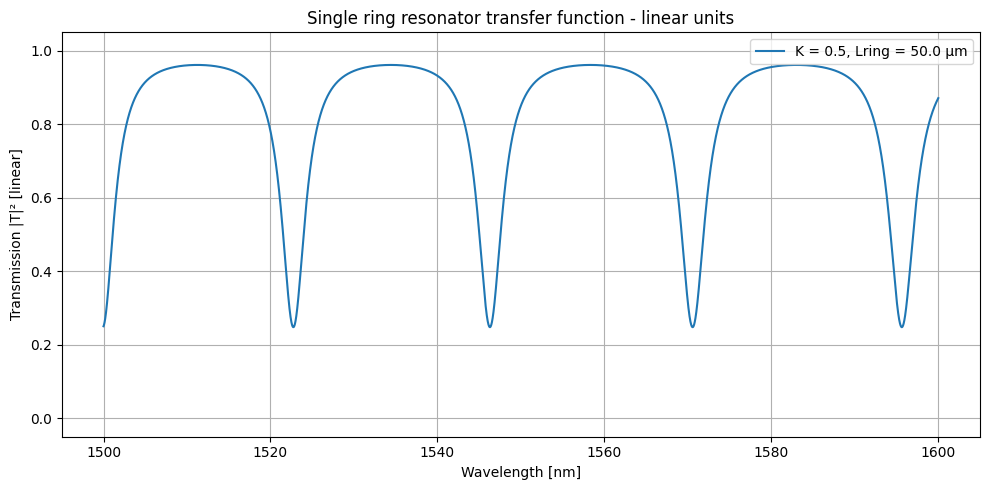

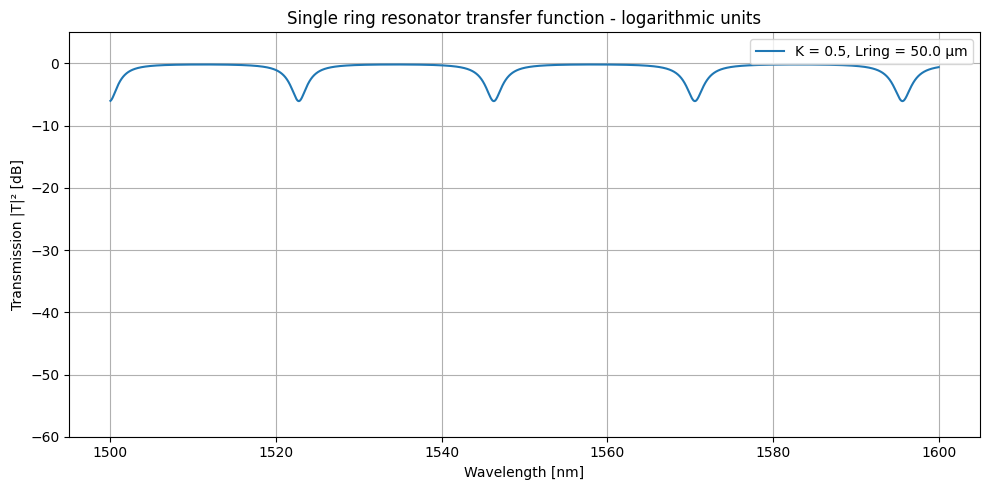

In [19]:

plt.figure(figsize=(10, 5))
plt.plot(wl_nm, P, label=f"K = {K}, Lring = {L_ring:.1f} µm")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Transmission |T|² [linear]")
plt.title("Single ring resonator transfer function - linear units")
plt.ylim([-0.05, 1.05])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(wl_nm, P_dB, label=f"K = {K}, Lring = {L_ring:.1f} µm")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Transmission |T|² [dB]")
plt.title("Single ring resonator transfer function - logarithmic units")
plt.ylim([-60, 5])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
dips, props = find_peaks(-P, distance=10000)

wl_dips = wl_nm[dips]

print("Resonance wavelengths [nm]:")
print(wl_dips[:10])

# FSR entre resonancias consecutivas
fsr_values = np.diff(wl_dips)

print("\nFSR values [nm]:")
print(fsr_values[:10])

fsr_mean = np.mean(fsr_values)

print(f"\nMean numerical FSR = {fsr_mean:.3f} nm")

Resonance wavelengths [nm]:
[1522.743 1546.289 1570.575 1595.635]

FSR values [nm]:
[23.546 24.286 25.06 ]

Mean numerical FSR = 24.297 nm


In [45]:
# FSR = 15 nm

lambda0_um = 1.55       # 1550 nm
FSR_nm = 15.0       # objetivo del FSR = 15nm
FSR_um = FSR_nm / 1000  # nm -> um

ng = 2.0                # indice de grupo

L_ring_design = lambda0_um**2 / (ng * FSR_um)   # obtener L_ring

print(f"L_ring = {L_ring_design:.3f} um")

L_ring = 80.083 um


In [47]:
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)  # um

K = 0.5
loss = 0.02      # dB/um

ring_test = ring_ap(
    wl=wl,
    wvg_ring={
        "length": L_ring_design,
        "loss": loss,
    },
    coup={
        "coupling": K,
    },
)

T = ring_test["in0", "out0"]

P = np.abs(T)**2

eps = 1e-20
P_dB = 10*np.log10(P + eps)

wl_nm = np.array(wl) * 1e3

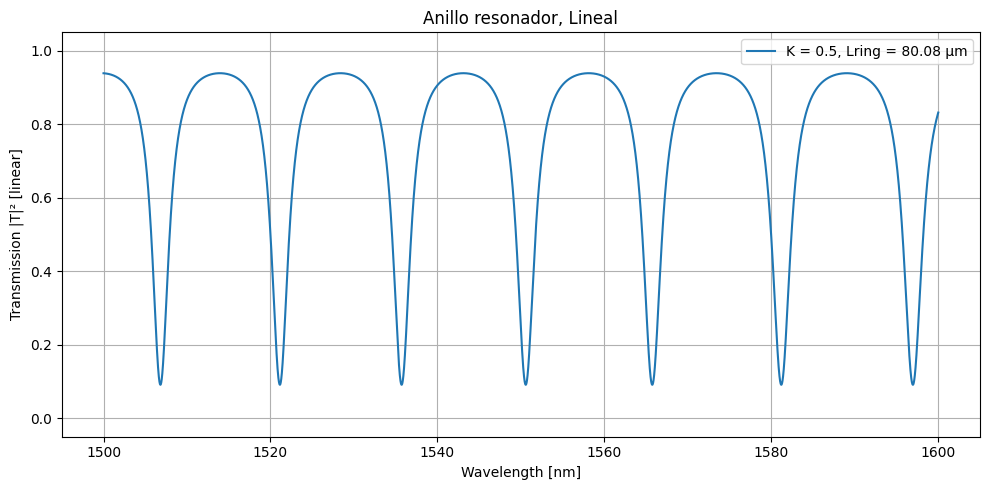

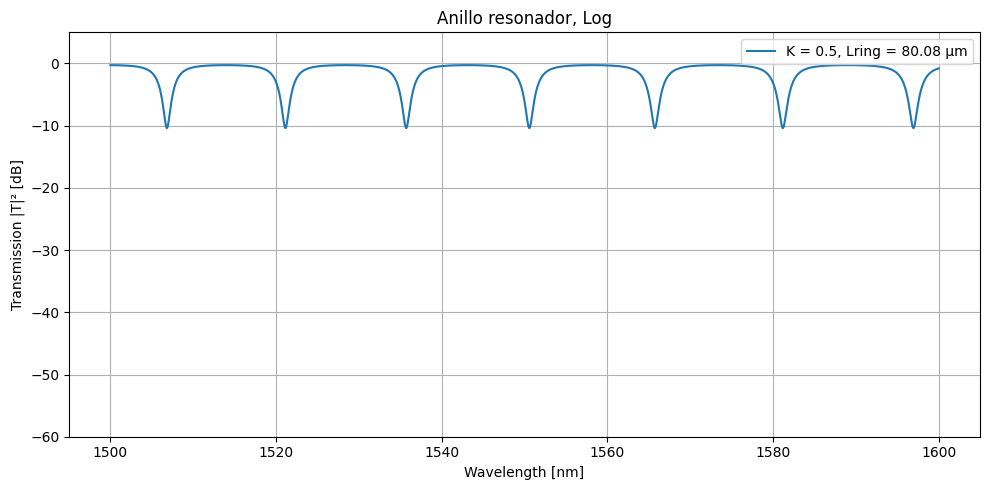

In [48]:


plt.figure(figsize=(10, 5))
plt.plot(wl_nm, P, label=f"K = {K}, Lring = {L_ring_design:.2f} µm")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Transmission |T|² [linear]")
plt.title("Anillo resonador, Lineal")
plt.ylim([-0.05, 1.05])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 5))
plt.plot(wl_nm, P_dB, label=f"K = {K}, Lring = {L_ring_design:.2f} µm")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Transmission |T|² [dB]")
plt.title("Anillo resonador, Log")
plt.ylim([-60, 5])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:

# Buscamos mínimos de transmisión
dips, props = find_peaks(-P, distance=8000)

wl_dips = wl_nm[dips]

print("Resonance wavelengths [nm]:")
print(wl_dips[:10])

fsr_values = np.diff(wl_dips)

print("\nFSR values [nm]:")
print(fsr_values[:10])

fsr_mean = np.mean(fsr_values)

print(f"\nMean numerical FSR = {fsr_mean:.3f} nm")

Resonance wavelengths [nm]:
[1506.818 1521.128 1535.713 1550.58  1565.738 1581.195 1596.961]

FSR values [nm]:
[14.31  14.585 14.867 15.158 15.457 15.766]

Mean numerical FSR = 15.024 nm


In [25]:

Pmax = np.max(P)
Pmin = np.min(P)

ER_dB = 10*np.log10((Pmax + eps)/(Pmin + eps))

print(f"Pmax = {Pmax:.6f}")
print(f"Pmin = {Pmin:.6f}")
print(f"Extinction Ratio = {ER_dB:.3f} dB")

Pmax = 0.938848
Pmin = 0.091326
Extinction Ratio = 10.120 dB


In [26]:
round_trip_loss_dB = loss * L_ring_design

Kcrit = 1 - 10**(-round_trip_loss_dB / 10)

print(f"Round-trip loss = {round_trip_loss_dB:.3f} dB")
print(f"Critical coupling coefficient Kcrit = {Kcrit:.4f}")

Round-trip loss = 1.602 dB
Critical coupling coefficient Kcrit = 0.3084


Critical coupling K = 0.3084
ER at critical coupling = 99.369 dB


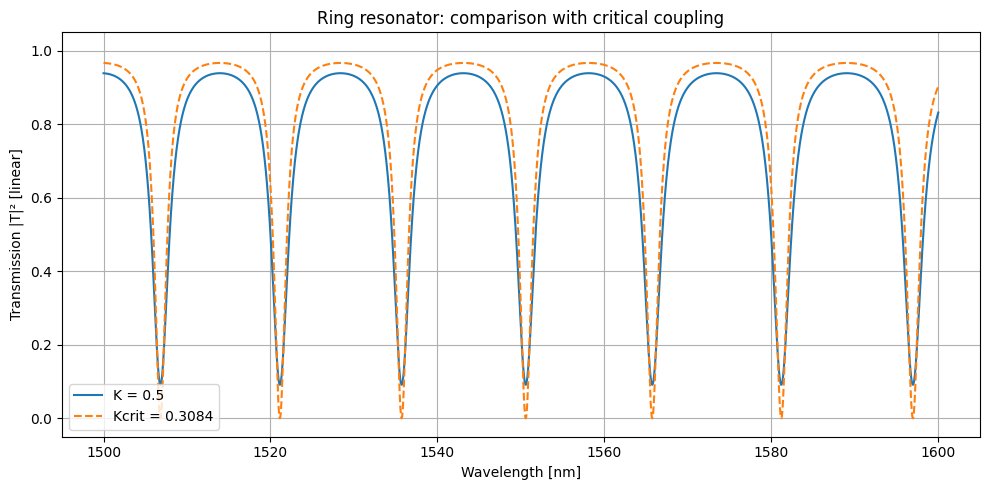

In [27]:

ring_test_crit = ring_ap(
    wl=wl,
    wvg_ring={
        "length": L_ring_design,
        "loss": loss,
    },
    coup={
        "coupling": Kcrit,
    },
)

Tcrit = ring_test_crit["in0", "out0"]

Pcrit = np.abs(Tcrit)**2
Pcrit_dB = 10*np.log10(Pcrit + eps)

Pmax_crit = np.max(Pcrit)
Pmin_crit = np.min(Pcrit)

ERcrit_dB = 10*np.log10((Pmax_crit + eps)/(Pmin_crit + eps))

print(f"Critical coupling K = {Kcrit:.4f}")
print(f"ER at critical coupling = {ERcrit_dB:.3f} dB")

plt.figure(figsize=(10, 5))
plt.plot(wl_nm, P, label=f"K = 0.5")
plt.plot(wl_nm, Pcrit, "--", label=f"Kcrit = {Kcrit:.4f}")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Transmission |T|² [linear]")
plt.title("Ring resonator: comparison with critical coupling")
plt.ylim([-0.05, 1.05])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

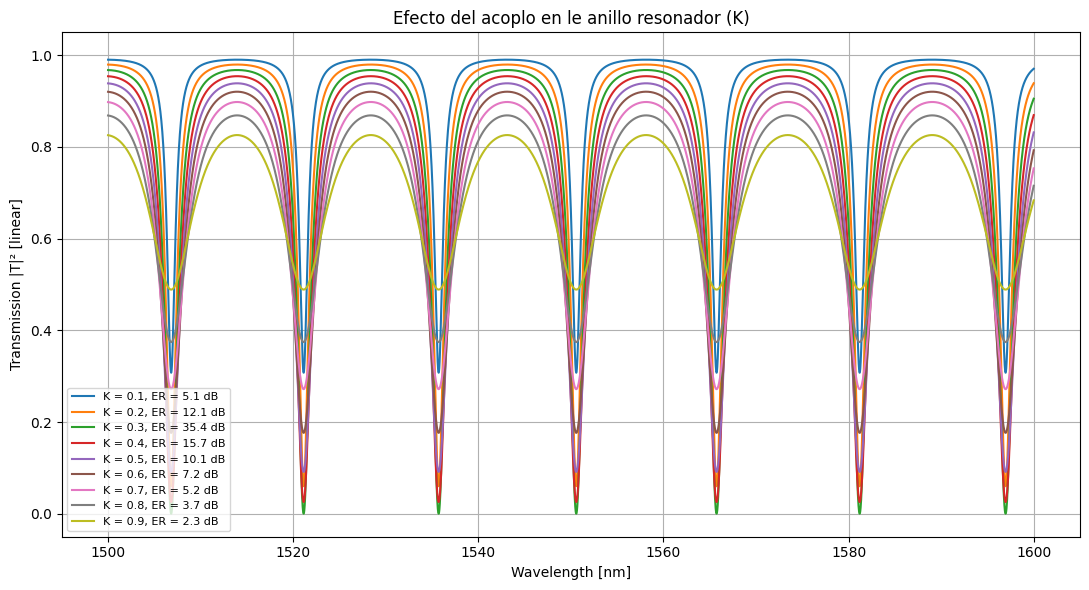

In [49]:
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)  # um
wl_nm = np.array(wl) * 1e3


lambda0_um = 1.55
FSR_nm = 15.0
FSR_um = FSR_nm / 1000
ng = 2.0

L_ring = lambda0_um**2 / (ng * FSR_um)

# Loss used in previous ring example
loss = 0.02  # dB/um

# K values
K_values = np.arange(0.1, 1.0, 0.1)

# Store results
results = []

plt.figure(figsize=(11, 6))

for K in K_values:
    ring_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": L_ring,
            "loss": loss,
        },
        coup={
            "coupling": K,
        },
    )

    T = ring_test["in0", "out0"]
    P = np.abs(T)**2

    Pmax = np.max(P)
    Pmin = np.min(P)
    ER_dB = 10*np.log10((Pmax + 1e-20)/(Pmin + 1e-20))

    results.append([K, Pmax, Pmin, ER_dB])

    plt.plot(wl_nm, P, label=f"K = {K:.1f}, ER = {ER_dB:.1f} dB")

plt.xlabel("Wavelength [nm]")
plt.ylabel("Transmission |T|² [linear]")
plt.title("Efecto del acoplo en le anillo resonador (K)")
plt.ylim([-0.05, 1.05])
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [29]:


print("K      Pmax        Pmin        ER [dB]")
print("------------------------------------------")

for K, Pmax, Pmin, ER_dB in results:
    print(f"{K:.1f}   {Pmax:.6f}   {Pmin:.6f}   {ER_dB:.3f}")

K      Pmax        Pmin        ER [dB]
------------------------------------------
0.1   0.990362   0.307682   5.077
0.2   0.979714   0.060133   12.120
0.3   0.967823   0.000276   35.446
0.4   0.954361   0.025665   15.704
0.5   0.938848   0.091326   10.120
0.6   0.920525   0.176486   7.173
0.7   0.898084   0.271807   5.191
0.8   0.868899   0.374537   3.655
0.9   0.825974   0.488975   2.277


In [50]:


round_trip_loss_dB = loss * L_ring

Kcrit = 1 - 10**(-round_trip_loss_dB / 10)

print(f"L_ring = {L_ring:.3f} um")
print(f"Perdida = {round_trip_loss_dB:.3f} dB")
print(f"Critical coupling Kcrit = {Kcrit:.4f}")

K_closest = K_values[np.argmin(np.abs(K_values - Kcrit))]



L_ring = 80.083 um
Perdida = 1.602 dB
Critical coupling Kcrit = 0.3084


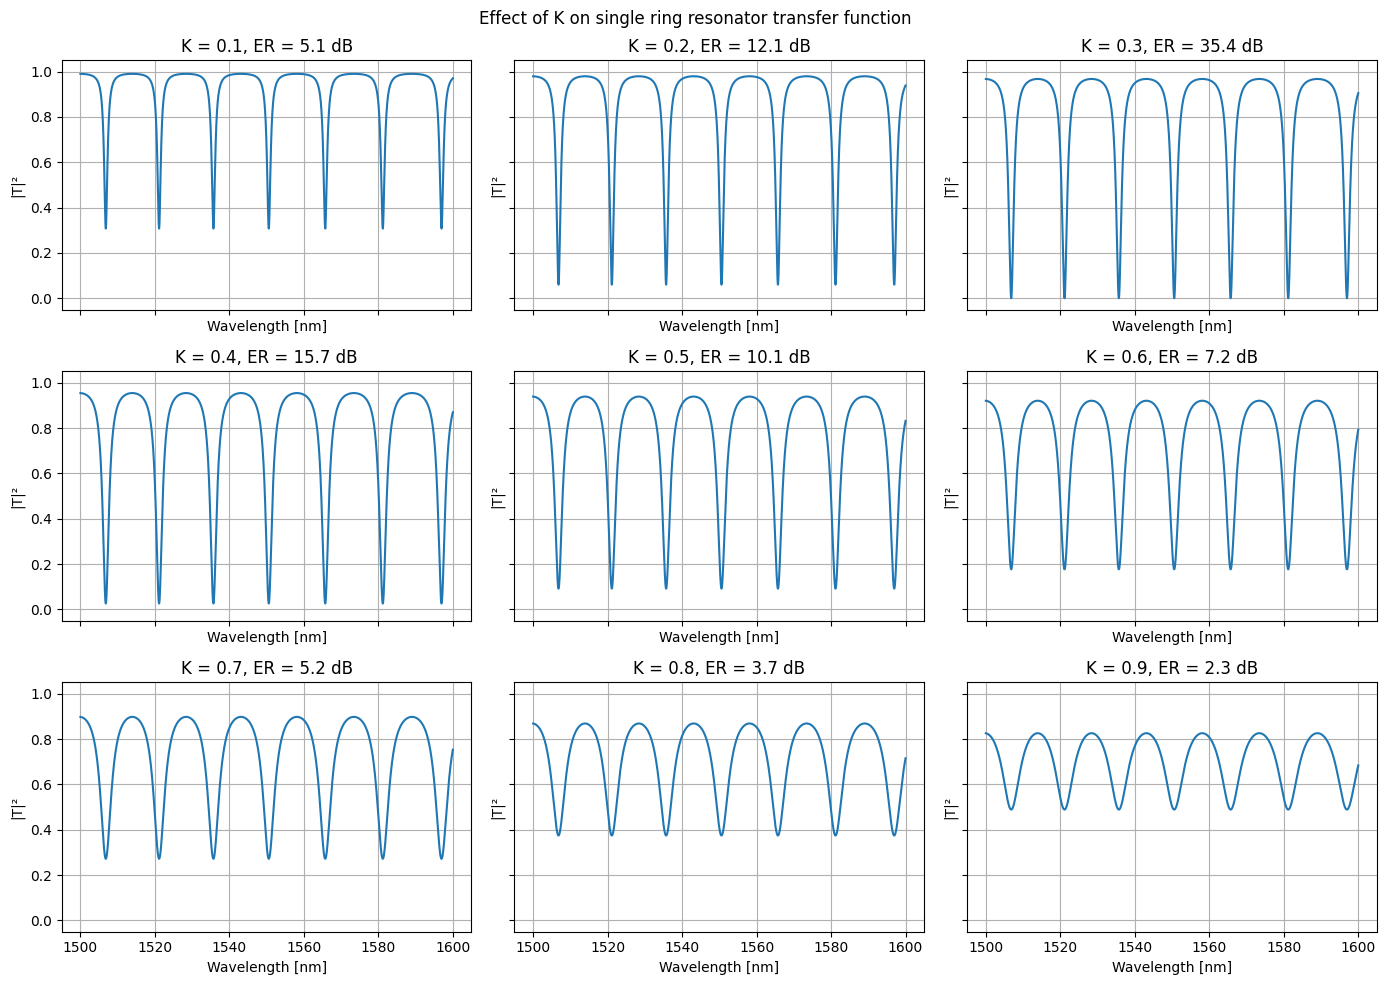

In [31]:


fig, ax = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

ax = ax.ravel()

for i, K in enumerate(K_values):
    ring_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": L_ring,
            "loss": loss,
        },
        coup={
            "coupling": K,
        },
    )

    T = ring_test["in0", "out0"]
    P = np.abs(T)**2

    Pmax = np.max(P)
    Pmin = np.min(P)
    ER_dB = 10*np.log10((Pmax + 1e-20)/(Pmin + 1e-20))

    ax[i].plot(wl_nm, P)
    ax[i].set_title(f"K = {K:.1f}, ER = {ER_dB:.1f} dB")
    ax[i].set_ylim([-0.05, 1.05])
    ax[i].grid(True)

for i in range(9):
    ax[i].set_xlabel("Wavelength [nm]")
    ax[i].set_ylabel("|T|²")

plt.suptitle("Effect of K on single ring resonator transfer function")
plt.tight_layout()
plt.show()

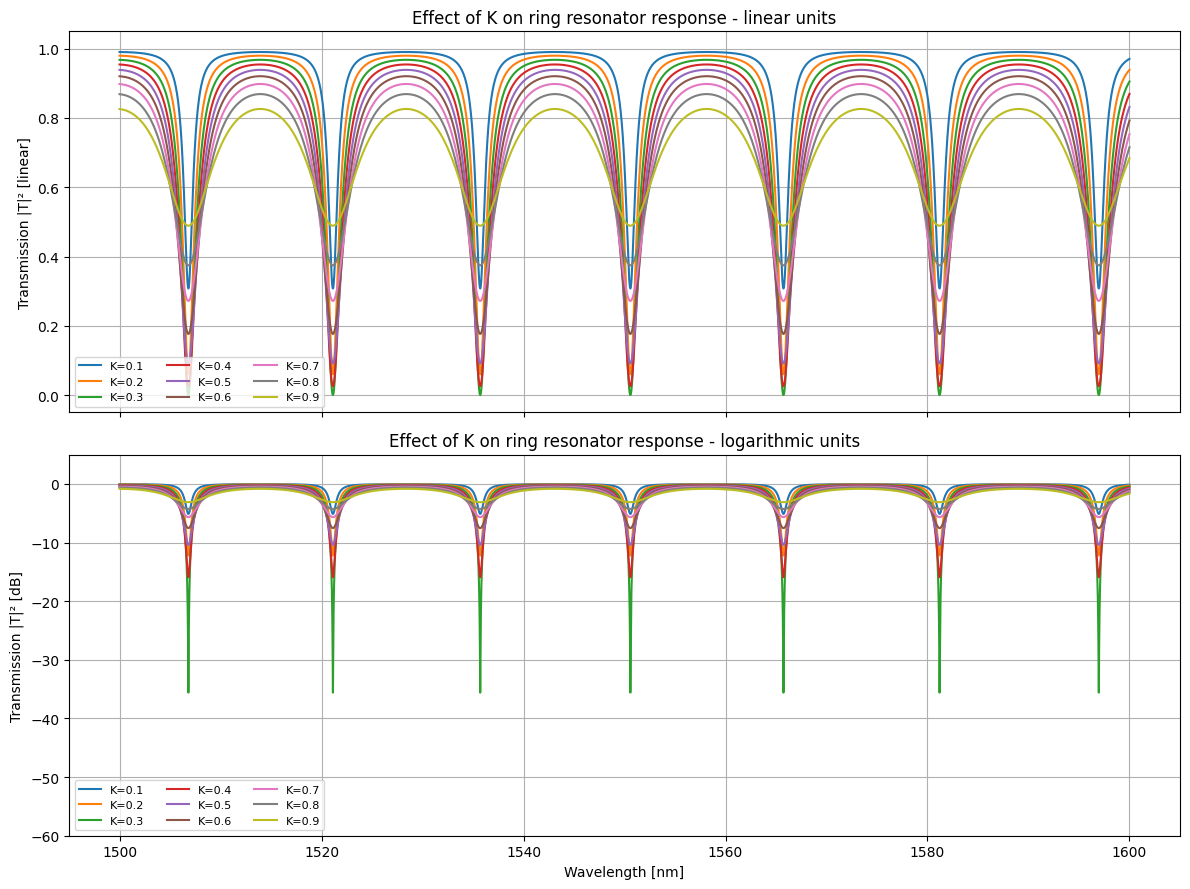

In [32]:
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)  # um
wl_nm = np.array(wl) * 1e3

# Ring parameters
lambda0_um = 1.55
FSR_nm = 15.0
FSR_um = FSR_nm / 1000
ng = 2.0

L_ring = lambda0_um**2 / (ng * FSR_um)
loss = 0.02  # dB/um

K_values = np.arange(0.1, 1.0, 0.1)

results = []

fig, ax = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for K in K_values:
    ring_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": L_ring,
            "loss": loss,
        },
        coup={
            "coupling": K,
        },
    )

    T = ring_test["in0", "out0"]
    P = np.abs(T)**2
    P_dB = 10*np.log10(P + 1e-20)

    Pmax = np.max(P)
    Pmin = np.min(P)
    ER_dB = 10*np.log10((Pmax + 1e-20)/(Pmin + 1e-20))

    results.append([K, Pmax, Pmin, ER_dB])

    ax[0].plot(wl_nm, P, label=f"K={K:.1f}")
    ax[1].plot(wl_nm, P_dB, label=f"K={K:.1f}")

# Linear
ax[0].set_ylabel("Transmission |T|² [linear]")
ax[0].set_title("Effect of K on ring resonator response - linear units")
ax[0].set_ylim([-0.05, 1.05])
ax[0].grid(True)
ax[0].legend(fontsize=8, ncol=3)

# dB
ax[1].set_xlabel("Wavelength [nm]")
ax[1].set_ylabel("Transmission |T|² [dB]")
ax[1].set_title("Effect of K on ring resonator response - logarithmic units")
ax[1].set_ylim([-60, 5])
ax[1].grid(True)
ax[1].legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

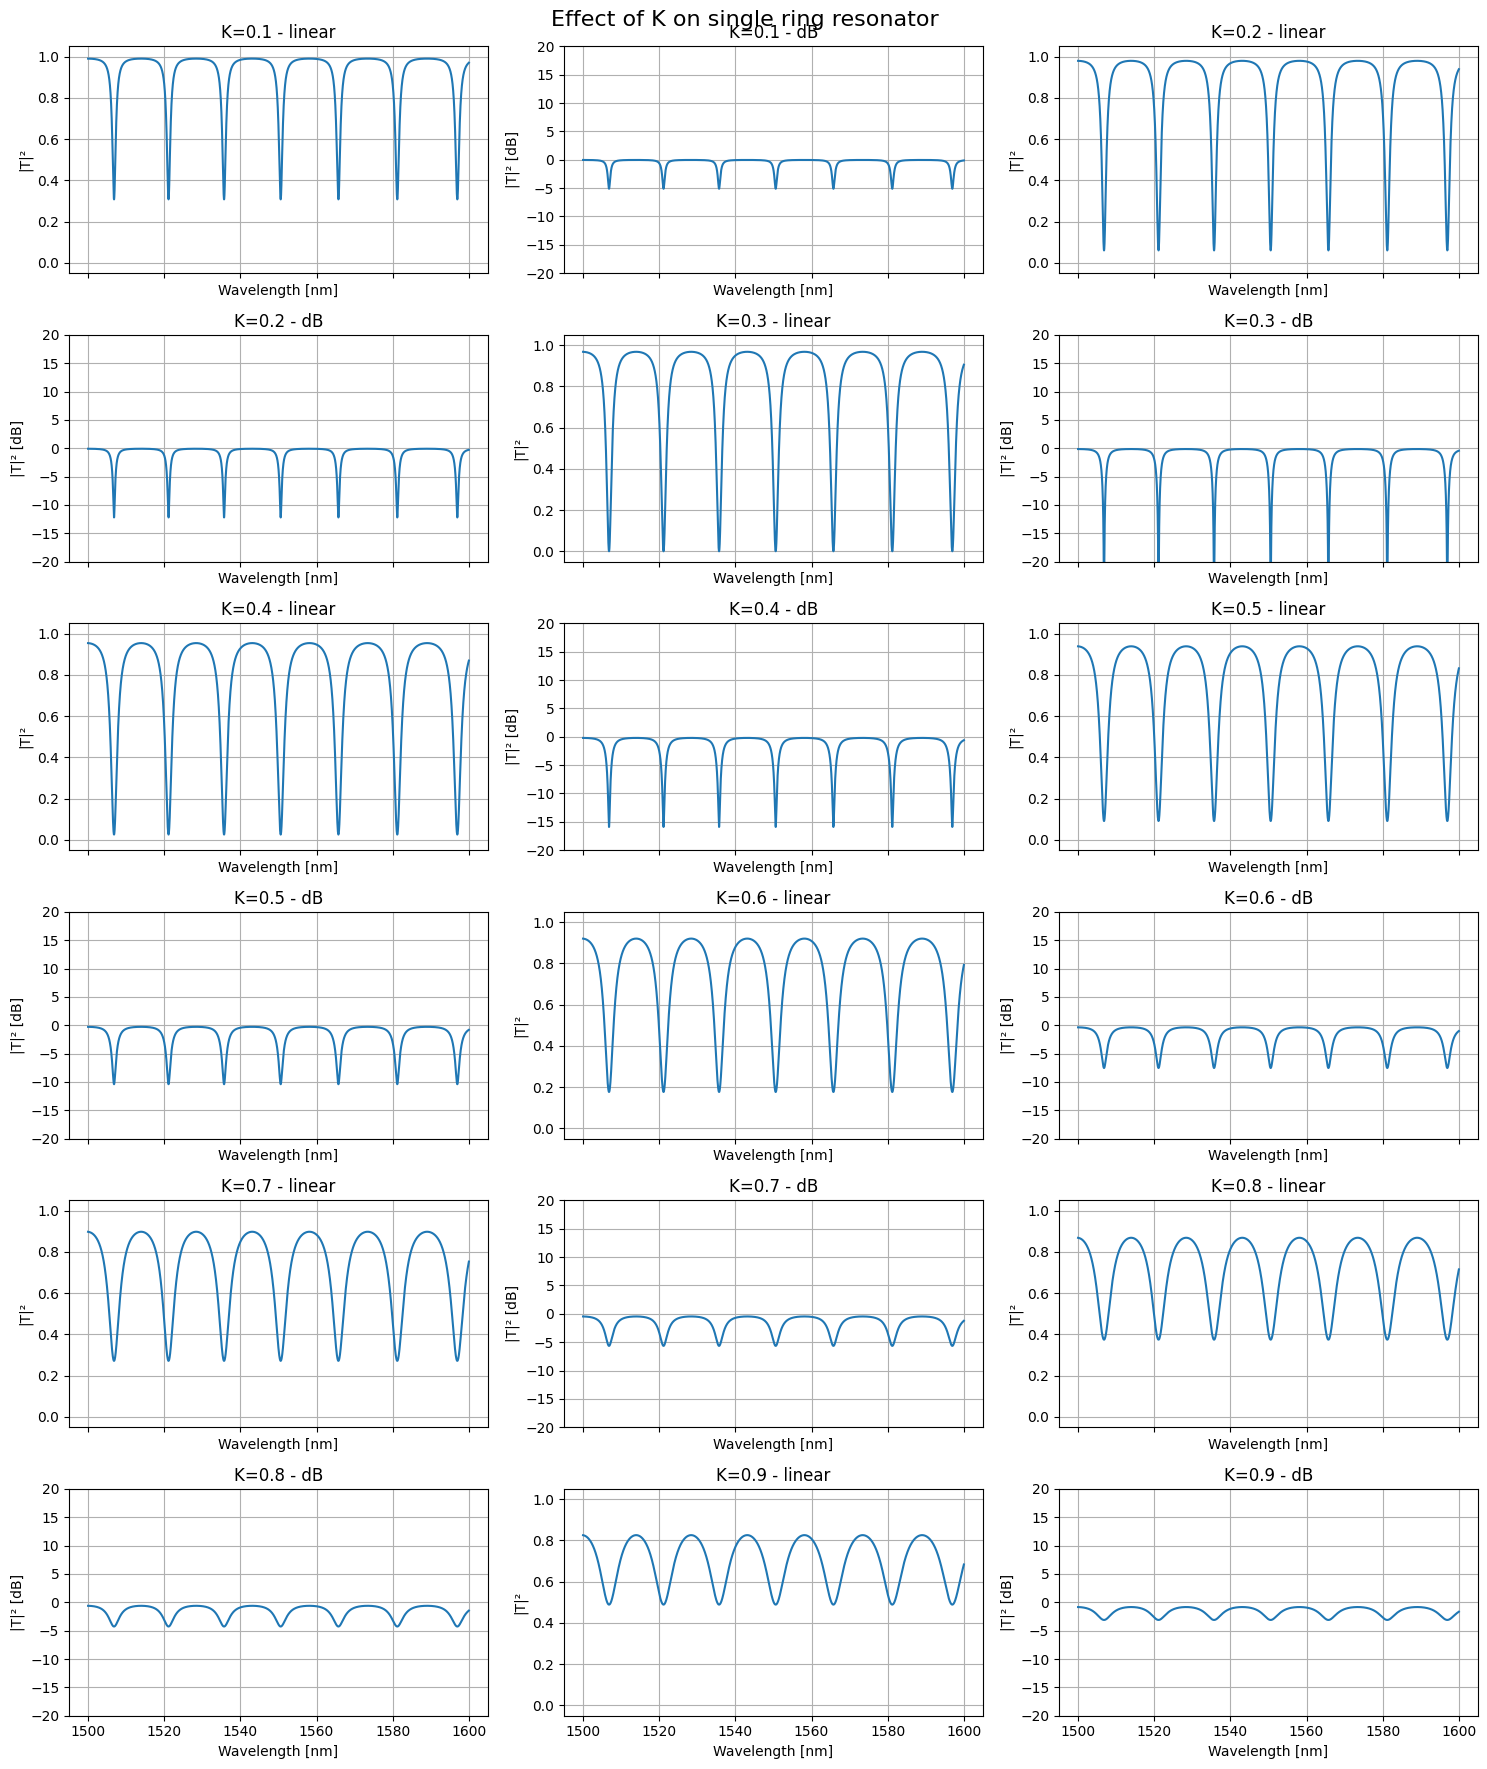

In [33]:


fig, ax = plt.subplots(6, 3, figsize=(15, 18), sharex=True)
ax = ax.ravel()

results = []

for i, K in enumerate(K_values):
    ring_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": L_ring,
            "loss": loss,
        },
        coup={
            "coupling": K,
        },
    )

    T = ring_test["in0", "out0"]
    P = np.abs(T)**2
    P_dB = 10*np.log10(P + 1e-20)

    Pmax = np.max(P)
    Pmin = np.min(P)
    ER_dB = 10*np.log10((Pmax + 1e-20)/(Pmin + 1e-20))
    results.append([K, Pmax, Pmin, ER_dB])

    # posición para lineal
    ax[2*i].plot(wl_nm, P)
    ax[2*i].set_title(f"K={K:.1f} - linear")
    ax[2*i].set_ylim([-0.05, 1.05])
    ax[2*i].grid(True)
    ax[2*i].set_ylabel("|T|²")

    # posición para dB
    ax[2*i + 1].plot(wl_nm, P_dB)
    ax[2*i + 1].set_title(f"K={K:.1f} - dB")
    ax[2*i + 1].set_ylim([-20, 20])
    ax[2*i + 1].grid(True)
    ax[2*i + 1].set_ylabel("|T|² [dB]")

for a in ax:
    a.set_xlabel("Wavelength [nm]")

plt.suptitle("Effect of K on single ring resonator", fontsize=16)
plt.tight_layout()
plt.show()

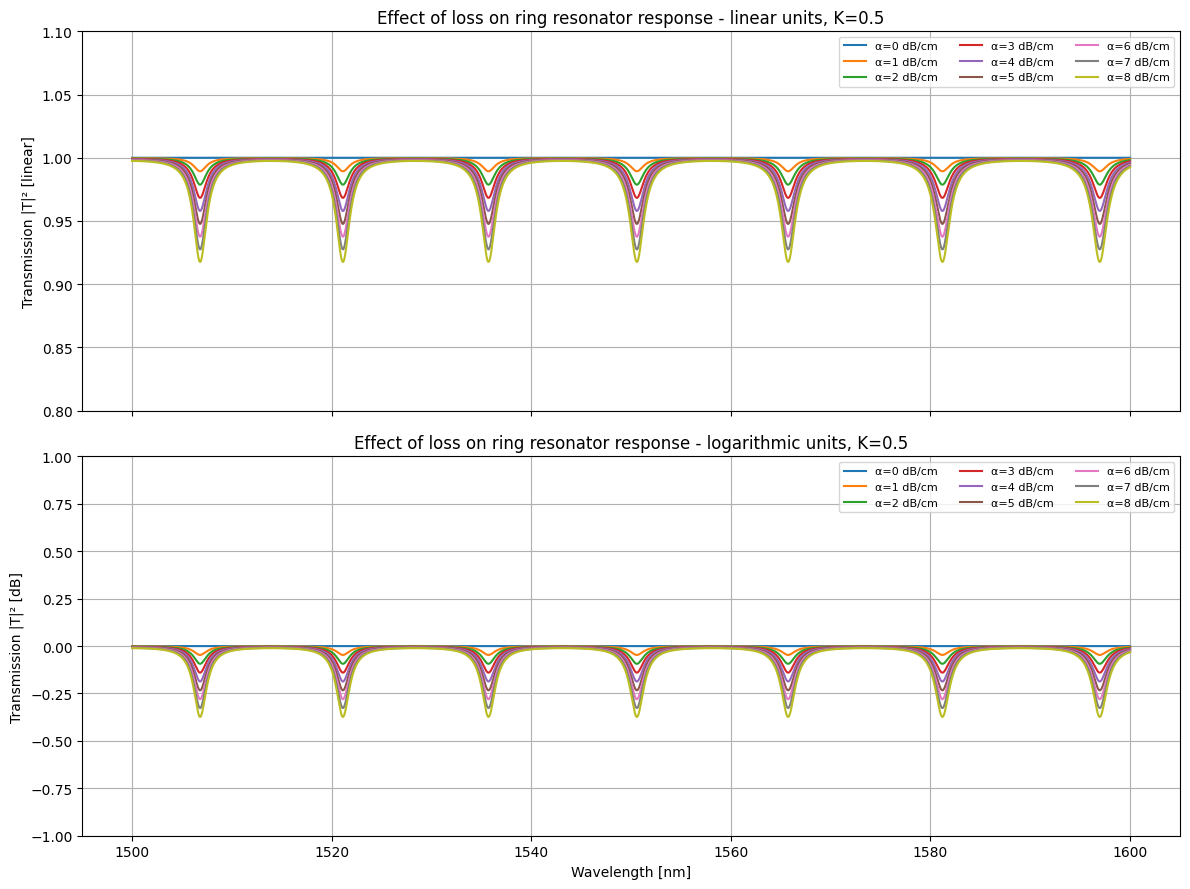

In [34]:
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)  # um
wl_nm = np.array(wl) * 1e3

# FSR = 15 nm
lambda0_um = 1.55
FSR_nm = 15.0
FSR_um = FSR_nm / 1000
ng = 2.0

L_ring = lambda0_um**2 / (ng * FSR_um)

# Fixed coupling coefficient
# If no K is specified in the exercise, we keep K constant.
K = 0.5

# Loss values in dB/cm
loss_values_db_cm = np.arange(0, 9, 1)

results_loss = []

fig, ax = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for loss_db_cm in loss_values_db_cm:

    # Convert dB/cm to dB/um
    loss_db_um = loss_db_cm / 10000.0

    ring_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": L_ring,
            "loss": loss_db_um,
        },
        coup={
            "coupling": K,
        },
    )

    T = ring_test["in0", "out0"]

    P = np.abs(T)**2
    P_dB = 10*np.log10(P + 1e-20)

    Pmax = np.max(P)
    Pmin = np.min(P)
    ER_dB = 10*np.log10((Pmax + 1e-20)/(Pmin + 1e-20))

    # Critical coupling value for this loss
    round_trip_loss_dB = loss_db_um * L_ring
    Kcrit = 1 - 10**(-round_trip_loss_dB / 10)

    results_loss.append([loss_db_cm, loss_db_um, Pmax, Pmin, ER_dB, Kcrit])

    ax[0].plot(wl_nm, P, label=f"α={loss_db_cm} dB/cm")
    ax[1].plot(wl_nm, P_dB, label=f"α={loss_db_cm} dB/cm")

# Linear plot
ax[0].set_ylabel("Transmission |T|² [linear]")
ax[0].set_title(f"Effect of loss on ring resonator response - linear units, K={K}")
ax[0].set_ylim([0.8, 1.1])
ax[0].grid(True)
ax[0].legend(fontsize=8, ncol=3)

# dB plot
ax[1].set_xlabel("Wavelength [nm]")
ax[1].set_ylabel("Transmission |T|² [dB]")
ax[1].set_title(f"Effect of loss on ring resonator response - logarithmic units, K={K}")
ax[1].set_ylim([-1, 1])
ax[1].grid(True)
ax[1].legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

In [51]:
print("alpha [dB/cm]   alpha [dB/um]      Pmax        Pmin        ER [dB]     Kcrit")
print("--------------------------------------------------------------------------------")

for loss_db_cm, loss_db_um, Pmax, Pmin, ER_dB, Kcrit in results_loss:
    print(f"{loss_db_cm:6.1f}        {loss_db_um:.8f}     {Pmax:.6f}   {Pmin:.6f}   {ER_dB:8.3f}   {Kcrit:.6f}")

# Find the case closest to critical coupling
Kcrit_values = np.array([row[5] for row in results_loss])
loss_values = np.array([row[0] for row in results_loss])

idx_closest = np.argmin(np.abs(Kcrit_values - K))

print("\nMas cerca del acoplamiento critico:")
print(f"alpha = {loss_values[idx_closest]:.1f} dB/cm")
print(f"K = {K:.3f}")
print(f"Kcrit = {Kcrit_values[idx_closest]:.6f}")

alpha [dB/cm]   alpha [dB/um]      Pmax        Pmin        ER [dB]     Kcrit
--------------------------------------------------------------------------------
   0.0        0.00000000     1.000000   1.000000      0.000   0.000000
   1.0        0.00010000     0.999684   0.989310      0.045   0.001842
   2.0        0.00020000     0.999367   0.978734      0.091   0.003681
   3.0        0.00030000     0.999051   0.968271      0.136   0.005517
   4.0        0.00040000     0.998735   0.957919      0.181   0.007349
   5.0        0.00050000     0.998419   0.947678      0.227   0.009178
   6.0        0.00060000     0.998104   0.937545      0.272   0.011003
   7.0        0.00070000     0.997788   0.927520      0.317   0.012825
   8.0        0.00080000     0.997472   0.917600      0.362   0.014644

Mas cerca del acoplamiento critico:
alpha = 8.0 dB/cm
K = 0.900
Kcrit = 0.014644


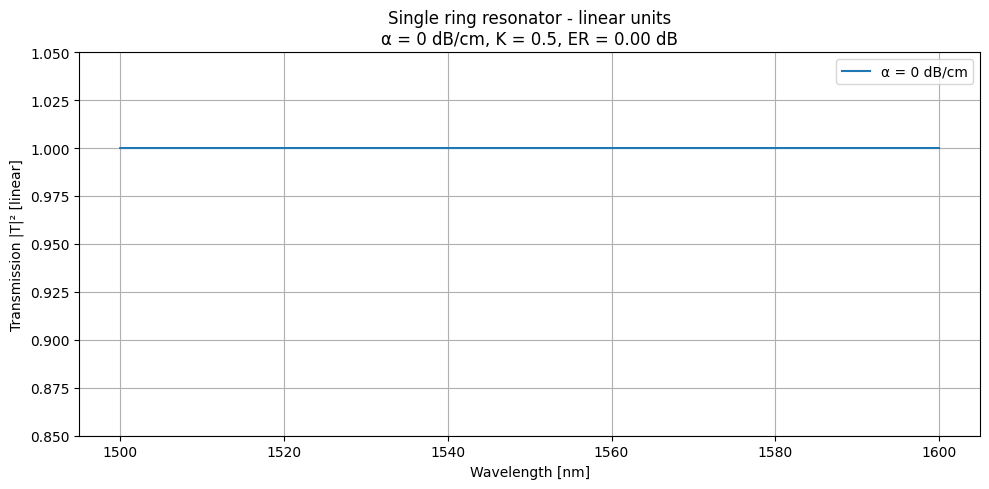

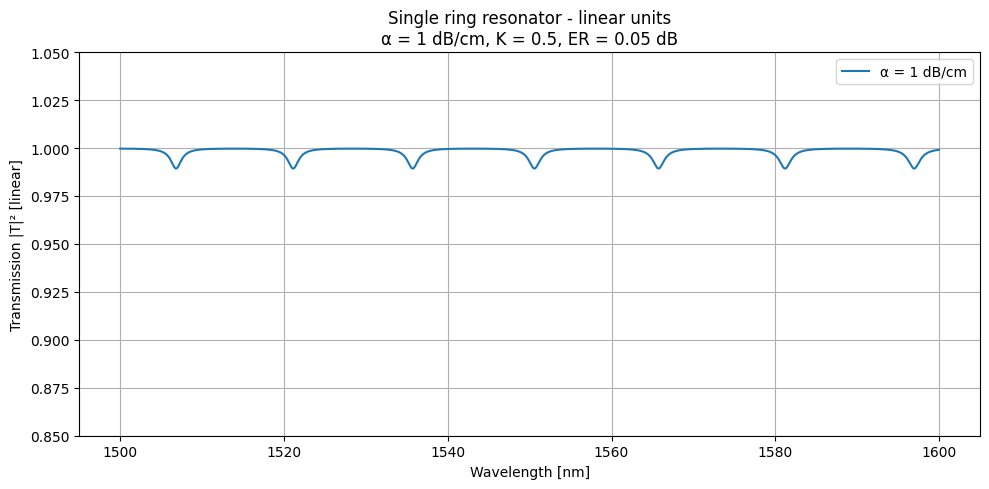

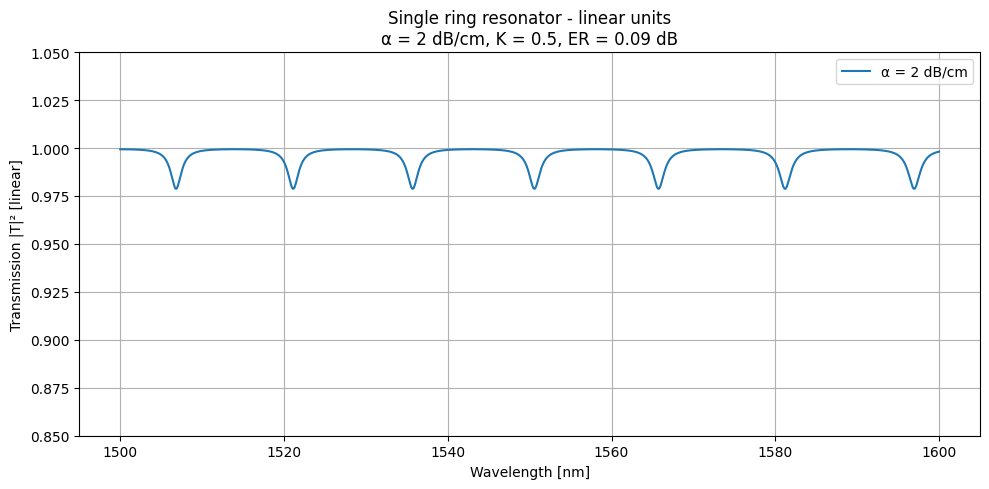

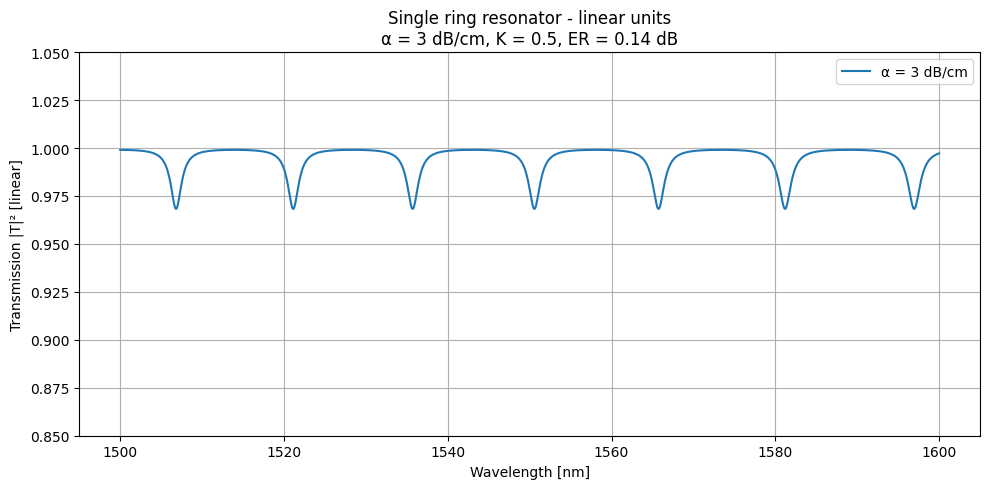

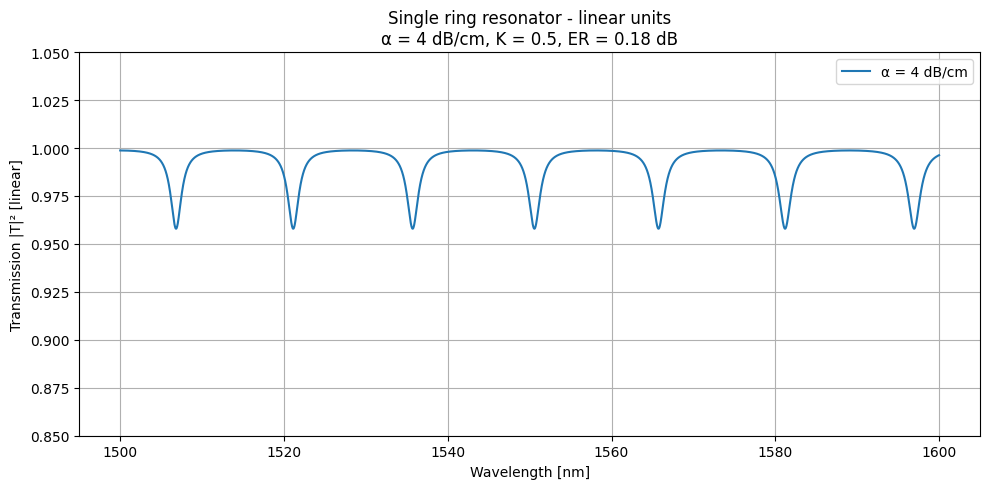

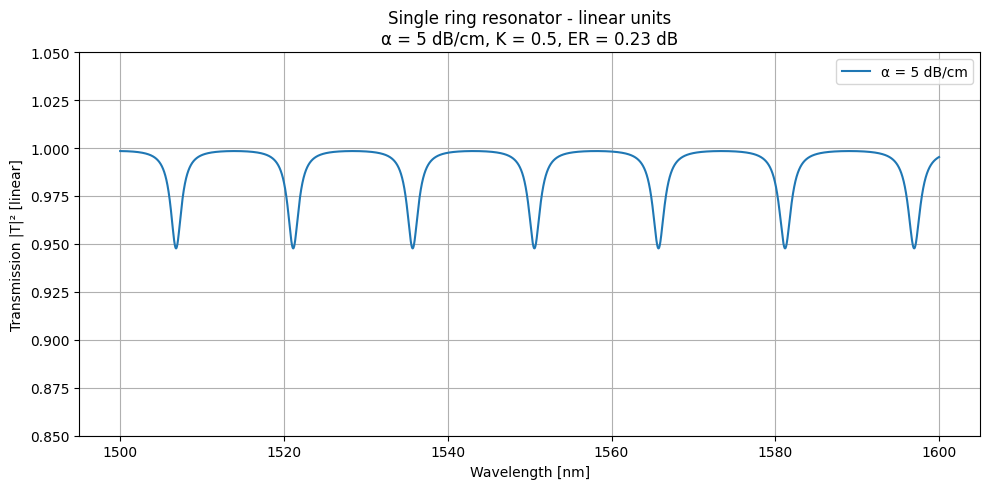

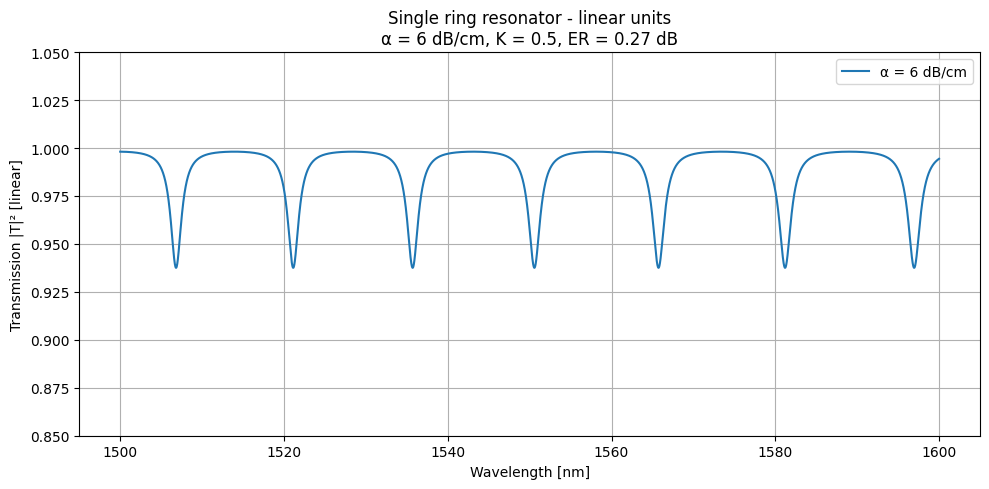

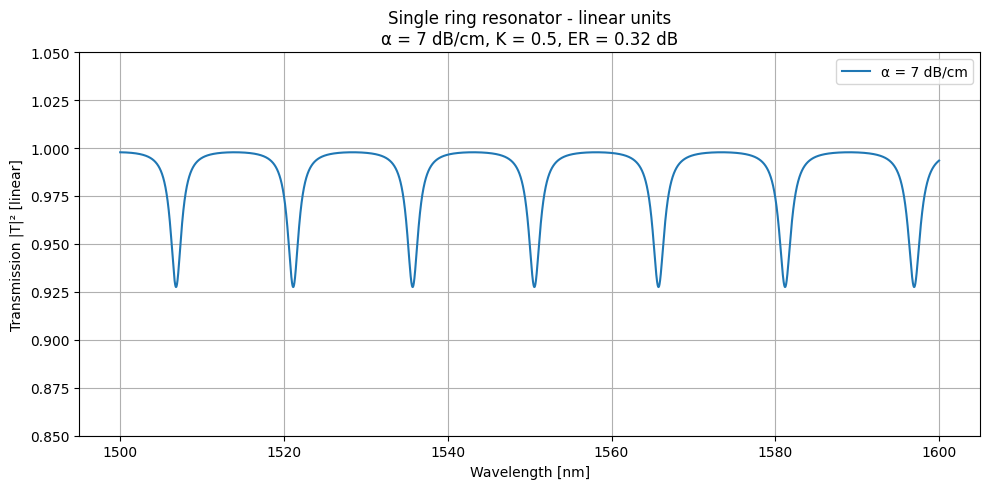

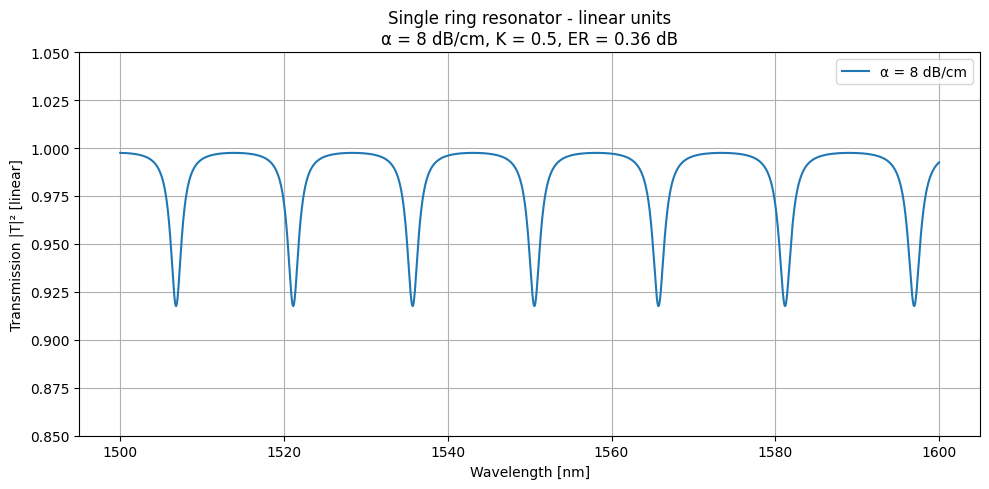

In [ ]:
wl = jnp.arange(1.500, 1.600 + 0.000001, 0.000001)   # um
wl_nm = np.array(wl) * 1e3

# Parámetros del anillo
lambda0_um = 1.55
FSR_nm = 15.0
FSR_um = FSR_nm / 1000
ng = 2.0

# Perímetro del anillo diseñado
L_ring = lambda0_um**2 / (ng * FSR_um)

# Acoplo fijo
K = 0.5

# Valores de atenuación en dB/cm
alpha_values_db_cm = np.arange(0, 9, 1)

for alpha_db_cm in alpha_values_db_cm:

    # Convertir de dB/cm a dB/um
    alpha_db_um = alpha_db_cm / 10000.0

    # Simulación del anillo
    ring_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": L_ring,
            "loss": alpha_db_um,
        },
        coup={
            "coupling": K,
        },
    )

    T = ring_test["in0", "out0"]
    P = np.abs(T)**2

    # Extinction Ratio por si quieres mostrarlo
    Pmax = np.max(P)
    Pmin = np.min(P)
    ER_dB = 10*np.log10((Pmax + 1e-20)/(Pmin + 1e-20))

    # Figura independiente
    plt.figure(figsize=(10, 5))
    plt.plot(wl_nm, P, label=f"α = {alpha_db_cm} dB/cm")
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Transmission |T|² [linear]")
    plt.title(f"Single ring resonator - linear units\nα = {alpha_db_cm} dB/cm, K = {K}, ER = {ER_dB:.2f} dB")
    plt.ylim([0.85, 1.05])
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

The resulting interference pattern again exhibits a periodic behavior. We define again the **free spectral range** (FSR), which should satisfy in this case the relationship:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,L_r}
$$

Where $L_r$ is the ring perimeter. Note that in our circuit model, we neglect the length of the coupler, so the perimeter is defined by the length of the waveguide sections.

#### **HINT**

You can perform parametric variations using the codes provided by us, for instance, check this casi in which we performed a loss sweep. 

Text(0, 0.5, '|H|^2 [dB]')

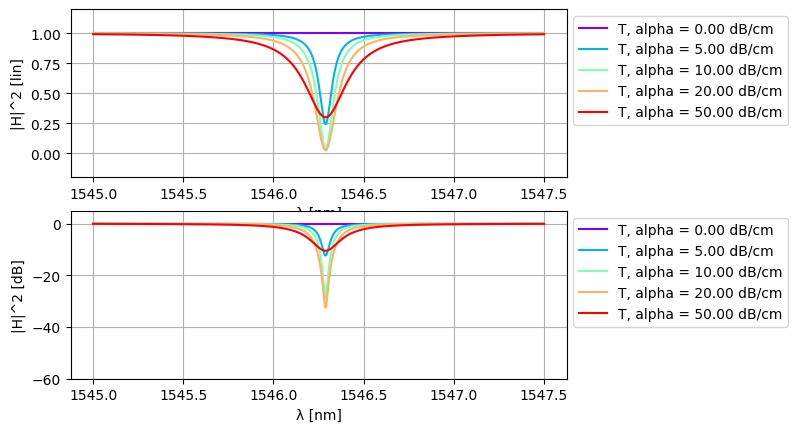

In [ ]:
# We change the wavelength range to "zoom in" into a resonance
wl = jnp.linspace(1.545, 1.5475, 1000)

# Now we perform a loss sweep
loss_dBum = 5e-4*np.array([0,1,2,4,10])

n_curves = np.shape(loss_dBum)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

ring_perimeter = 75.0
coupling = 0.025

fig, ax = plt.subplots(2,1)
#Update the variable you enumarate below
for i, loss in enumerate(loss_dBum):
    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": ring_perimeter, "loss": loss}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

Now use this code section to obtain the results of LOs4, 5, and 6.